##Credit Card Fraud Detection
What is Fraud Detection?

Fraud Detection is the process of identifying suspicious transactions that differ from normal customer behavior.

Example

Normal Transaction:
₹500 Grocery Purchase

Fraudulent Transaction:
₹50,000 Purchase from Unknown Location

In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [7]:
df = pd.read_csv("creditcard.csv.zip")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


#PCA Features

Columns:

V1, V2, V3 ... V28
 are PCA-transformed variables.

PCA (Principal Component Analysis) is a dimensionality reduction technique used to protect sensitive customer information while preserving patterns in the data.

In [8]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [9]:
df.duplicated().sum()

np.int64(1081)

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.duplicated().sum()

np.int64(0)

#FRAUD VS LEGIMITATE TRANSACTIONS

In [12]:
df['Class'].value_counts()

,count
Class,
0,283253
1,473


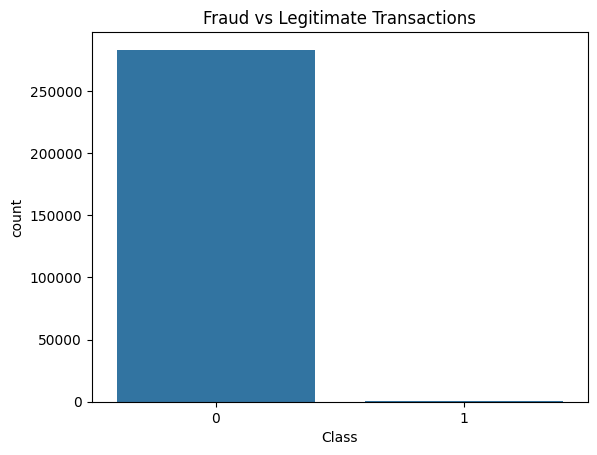

In [13]:
sns.countplot(x='Class', data=df)

plt.title("Fraud vs Legitimate Transactions")
plt.show()

LEGIMITATE >>>>>> FRAUD

In [14]:
fraud = df['Class'].value_counts()[1]

total = len(df)

print("Fraud Percentage:", (fraud/total)*100)

Fraud Percentage: 0.1667101358352777


#Imbalanced Dataset

A dataset where one class heavily outweighs another.

Fraud datasets are usually highly imbalanced.

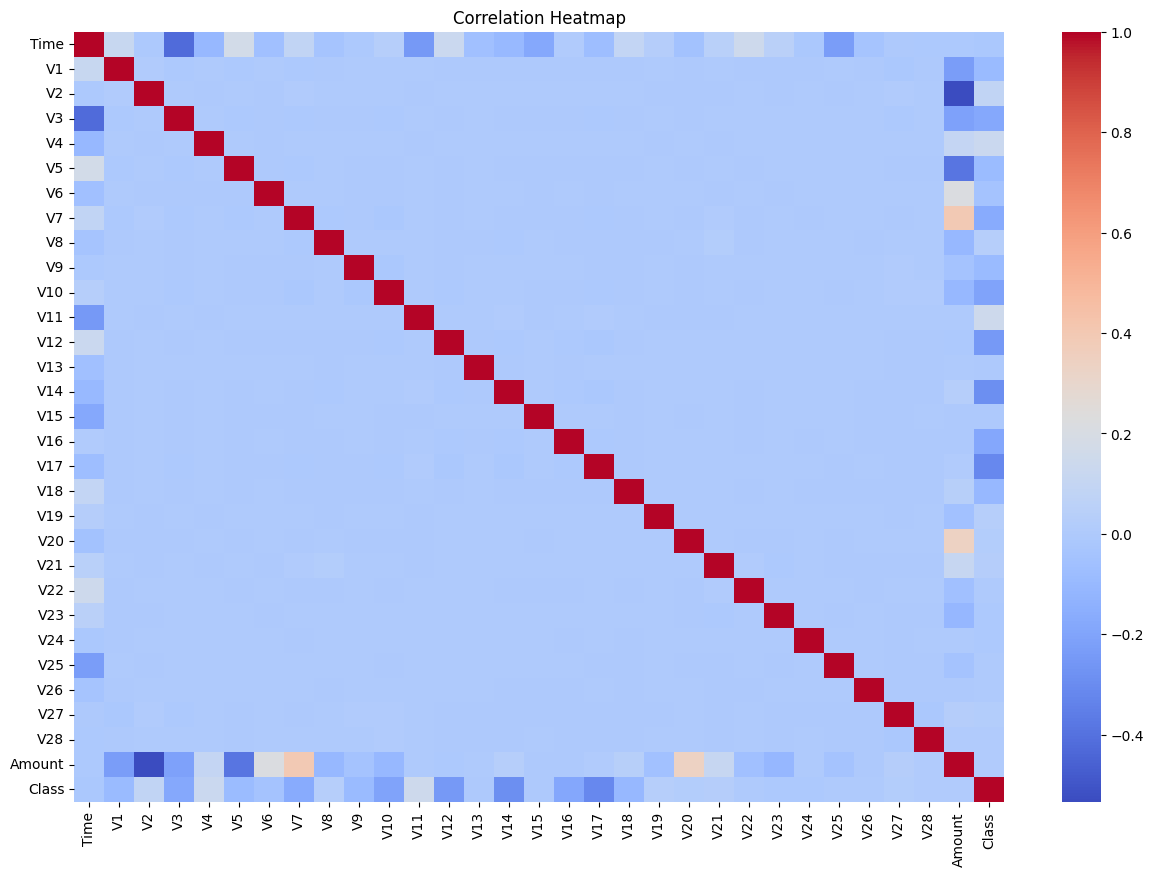

In [15]:
plt.figure(figsize=(15,10))

sns.heatmap(
    df.corr(),
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

#FEATURE SELECTION

Stratified Sampling ensures both fraud and non-fraud transactions are proportionally represented in train and test sets.

LOGISTIC REGRESSION Vs DECISION TREE

In [21]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

lr = LogisticRegression(
    max_iter=5000,
    class_weight='balanced',
    random_state=42
)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [22]:
print(
    "Logistic Regression Accuracy:",
    accuracy_score(y_test, lr_pred)
)

Logistic Regression Accuracy: 0.9753286575265216


In [23]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [24]:
print(
    "Decision Tree Accuracy:",
    accuracy_score(y_test, dt_pred)
)

Decision Tree Accuracy: 0.999048391076023


In [26]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree'
    ],
    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred)
    ]
})

print(results)

                 Model  Accuracy
0  Logistic Regression  0.975329
1        Decision Tree  0.999048


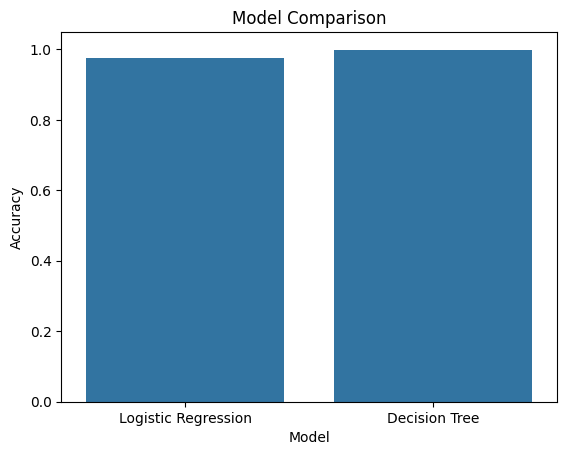

In [27]:
sns.barplot(
    x='Model',
    y='Accuracy',
    data=results
)

plt.title("Model Comparison")
plt.show()

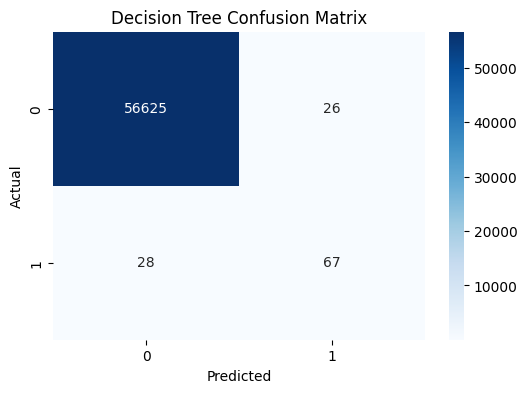

In [30]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, dt_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [32]:
sample = X_test[[0]]

prediction = dt.predict(sample)

if prediction[0] == 1:
    print("🚨 Fraudulent Transaction")
else:
    print("✅ Legitimate Transaction")

✅ Legitimate Transaction
